In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from notebook_utils import bootstrap_mean_and_ci

In [2]:
with open(f"../scripts/_cache/resnet18_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet18_saved = json.load(f)

with open(f"../scripts/_cache/resnet50_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    resnet50_saved = json.load(f)

with open(f"../scripts/_cache/vit_imagenet_2_per_class_stability_vs_smoothing.json") as f:
    vit_saved = json.load(f)

with open(f"../scripts/_cache/roberta_tweeteval_sentiment_stability_vs_smoothing.json") as f:
    roberta_saved = json.load(f)

In [3]:
def make_plot(saved, title, legend_loc=None, fs=16, xticks=None):
    lambda_to_rates = saved["lambda_to_rates"]
    radii = saved["radii"]

    fig, ax = plt.subplots(figsize=(4,3))
    for k in [1.0, 0.8, 0.6, 0.4, 0.2]:
        all_curves = np.array(lambda_to_rates[f"{k:.3f}"])
        mean, lb, ub = bootstrap_mean_and_ci(all_curves)
        ax.plot(radii, mean, label=f"$\lambda = {k:.1f}$")
        # ax.plot(radii, mean, label=f"{k:.1f}")
        # ax.plot(radii, mean)
        ax.fill_between(radii, lb, ub, alpha=0.2)
        # ax.plot(radii, np.median(lambda_to_rates[f"{k:.3f}"], axis=0), label=f"$\lambda = {k:.1f}$")

    ax.set_ylabel("Stability Rate", fontsize=fs)
    ax.set_xlabel("Perturbation Radius", fontsize=fs)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
    # title = None
    ax.legend(
        title=title,
        loc=legend_loc,
        title_fontsize=fs,
        fontsize=fs-2,
        # # bbox_to_anchor=(0.5, 1.15),
        # columnspacing=1.0,
        # ncol=5
        ncol=1,
    )
    return fig

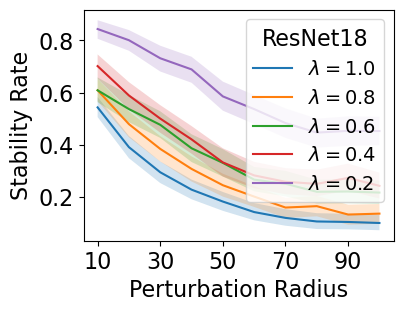

In [4]:
image_xticks = [10, 30, 50, 70, 90]
fig = make_plot(resnet18_saved, "ResNet18", legend_loc="upper right", xticks=image_xticks)
fig.savefig("_dump/stability_vs_smoothing_resnet18.pdf", bbox_inches="tight")

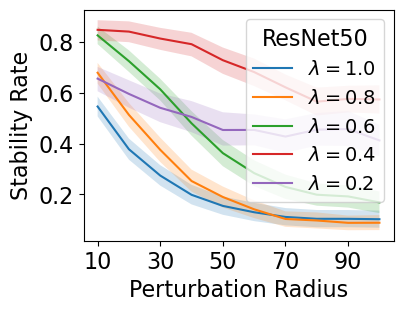

In [5]:
image_xticks = [10, 30, 50, 70, 90]
fig = make_plot(resnet50_saved, "ResNet50", legend_loc="upper right", xticks=image_xticks)
fig.savefig("_dump/stability_vs_smoothing_resnet50.pdf", bbox_inches="tight")

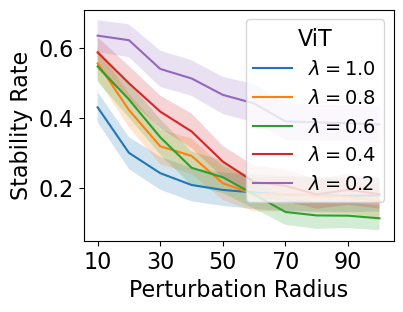

In [6]:
image_xticks = [10, 30, 50, 70, 90]
fig = make_plot(vit_saved, "ViT", legend_loc="upper right", xticks=image_xticks)
fig.savefig("_dump/stability_vs_smoothing_vit.pdf", bbox_inches="tight")

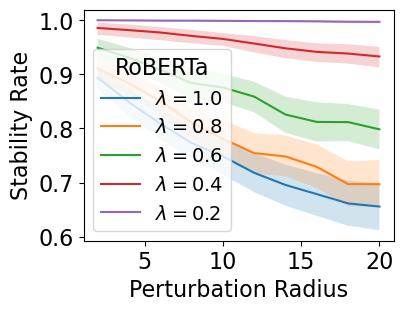

In [7]:
fig = make_plot(roberta_saved, "RoBERTa", legend_loc="lower left")
fig.savefig("_dump/stability_vs_smoothing_roberta.pdf", bbox_inches="tight")

In [8]:
plt.rcParams["axes.prop_cycle"].by_key()["color"]

['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']